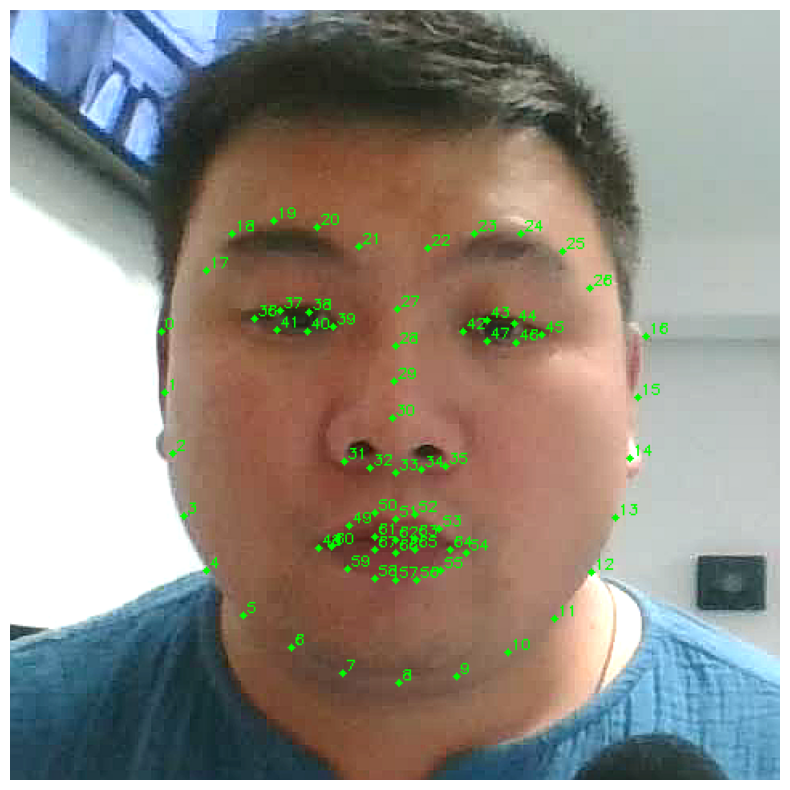

In [1]:
import cv2
import dlib
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 路径：68关键点模型（请根据你的实际路径修改）
predictor_path = r"E:\project\audio_visual_svr\visual\shape_predictor_68_face_landmarks.dat"

# 初始化 dlib 检测器和关键点预测器
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 加载图像
image_path = r"E:\data_gen\face\face_data\2023_10_12_左长青_0.bmp"
pil_img = Image.open(image_path).convert("RGB")
image = np.array(pil_img)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# 灰度化以用于检测
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

if len(faces) == 0:
    raise ValueError("未检测到人脸")

# 仅使用第一张脸
face = faces[0]
shape = predictor(gray, face)

# 标注 68 个关键点
for i in range(68):
    x, y = shape.part(i).x, shape.part(i).y
    cv2.circle(image, (x, y), 2, (0, 255, 0), -1)
    cv2.putText(image, str(i), (x + 2, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

# 显示结果
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
#plt.title("dlib 68点人脸关键点")
plt.show()


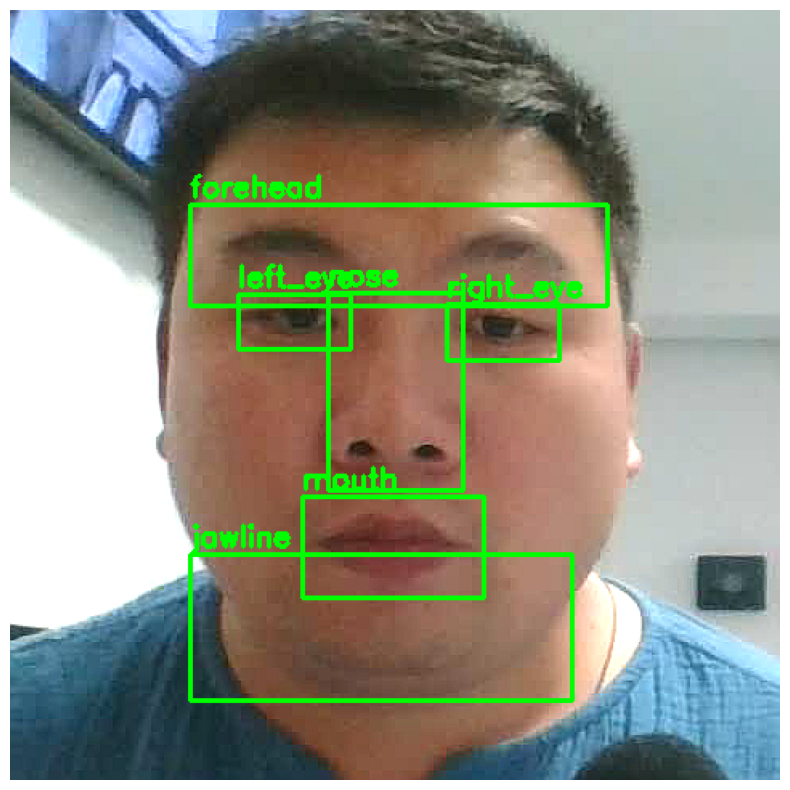

In [3]:
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 加载 dlib 的人脸检测器和关键点预测器
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")  # 确保这个模型文件存在

# Dlib版本的区域定义（基于68点）
FACE_REGIONS = {
    "forehead": list(range(17, 27)),  # 眉毛区域（没有额头只能近似）
    "left_eye": list(range(36, 42)),  # 左眼
    "right_eye": list(range(42, 48)),  # 右眼
    "nose": list(range(27, 36)),  # 鼻子
    "mouth": list(range(48, 68)),  # 嘴巴（含内外唇）
    "jawline": list(range(4, 12))  # 下巴轮廓
}

def read_image(image_path):
    try:
        pil_img = Image.open(image_path).convert("RGB")
        image = np.array(pil_img)[:, :, ::-1]
        return image
    except Exception as e:
        print(f"读取失败: {image_path}, 错误: {e}")
        return None

def visualize_regions(image_path):
    image = read_image(image_path)
    if image is None:
        return

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    if len(faces) == 0:
        print(f"未检测到人脸: {image_path}")
        return

    face = faces[0]  # 默认取第一张脸
    shape = predictor(gray, face)
    landmarks = np.array([[p.x, p.y] for p in shape.parts()])
    image_copy = image.copy()

    for region_name, indices in FACE_REGIONS.items():
        points = landmarks[indices]
        x, y, w_box, h_box = cv2.boundingRect(points)
        pad = 10
        x = max(x - pad, 0)
        y = max(y - pad, 0)
        x2 = min(x + w_box + pad * 2, image.shape[1])
        y2 = min(y + h_box + pad * 2, image.shape[0])

        # 画矩形框
        cv2.rectangle(image_copy, (x, y), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_copy, region_name, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
    #plt.title("使用Dlib划分人脸区域")
    plt.axis("off")
    plt.show()

# 示例路径
image_path = r"E:\data_gen\face\face_data\2023_10_12_左长青_0.bmp"
visualize_regions(image_path)


In [2]:
import cv2
import dlib
import os
import numpy as np
from PIL import Image

# 加载 dlib 的人脸检测器和 68 点关键点模型
predictor_path = r"E:\project\audio_visual_svr\visual\shape_predictor_68_face_landmarks.dat"  # 修改为你自己的路径
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(predictor_path)

# 基于 dlib 的人脸区域定义（基于68点）
FACE_REGIONS = {
    "forehead": list(range(17, 27)),      # 眉毛区域（没有额头只能近似）
    "left_eye": list(range(36, 42)),      # 左眼
    "right_eye": list(range(42, 48)),     # 右眼
    "nose": list(range(27, 36)),          # 鼻子
    "mouth": list(range(48, 68)),         # 嘴巴（含内外唇）
    "jawline": list(range(4, 12)),        # 下巴轮廓中段（排除两端）
}

def read_image(image_path):
    try:
        pil_img = Image.open(image_path).convert("RGB")
        image = np.array(pil_img)[:, :, ::-1]  # 转为 BGR 格式
        return image
    except Exception as e:
        print(f"PIL 读取失败: {image_path}，错误信息: {e}")
        return None

def extract_face_regions_from_image(image_path, output_base):
    image = read_image(image_path)
    if image is None:
        return False  # 返回失败标志

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    if len(faces) == 0:
        print(f"未检测到人脸: {image_path}")
        return False  # 返回失败标志

    shape = predictor(gray, faces[0])
    landmarks = np.array([[p.x, p.y] for p in shape.parts()])
    h, w, _ = image.shape

    for region_name, indices in FACE_REGIONS.items():
        points = landmarks[indices]
        x, y, w_box, h_box = cv2.boundingRect(points)

        # 扩展边界
        pad = 10
        x = max(x - pad, 0)
        y = max(y - pad, 0)
        x2 = min(x + w_box + pad * 2, w)
        y2 = min(y + h_box + pad * 2, h)

        region_crop = image[y:y2, x:x2]

        region_folder = os.path.join(output_base, region_name)
        os.makedirs(region_folder, exist_ok=True)

        filename = os.path.splitext(os.path.basename(image_path))[0]
        save_path = os.path.join(region_folder, f"{filename}.jpg")

        region_crop_rgb = cv2.cvtColor(region_crop, cv2.COLOR_BGR2RGB)
        Image.fromarray(region_crop_rgb).save(save_path)
        print(f"保存 {region_name} 区域图像到: {save_path}")

    return True  # 成功提取

def process_image_folder(input_folder, output_folder):
    total_images = 0
    total_output_regions = 0
    failed_images = []

    for file in os.listdir(input_folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            total_images += 1
            image_path = os.path.join(input_folder, file)

            region_count_before = count_total_images(output_folder)
            success = extract_face_regions_from_image(image_path, output_folder)
            region_count_after = count_total_images(output_folder)

            if not success:
                failed_images.append(file)

            total_output_regions += (region_count_after - region_count_before)

    print(f"\n总共读取图像数: {total_images}")
    print(f"总共输出区域图像数: {total_output_regions}")
    print(f"未检测到人脸的图像数: {len(failed_images)}")
    if failed_images:
        print("以下图像未能检测到人脸：")
        for f in failed_images:
            print(f" - {f}")

def count_total_images(folder):
    count = 0
    for root, _, files in os.walk(folder):
        count += len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])
    return count

# ==== 使用示例 ====
input_dir = r"E:\data_gen\face\new_face_data"         # 输入图像文件夹路径
output_dir = r"E:\data_gen\face\new_face_regions"     # 输出裁剪区域图像的路径
process_image_folder(input_dir, output_dir)


In [9]:
import os
import pandas as pd
from deepface import DeepFace
from tqdm import tqdm

# 模型列表
MODELS = ["VGG-Face", "Facenet", "ArcFace", "ResNet50"]

# 输入输出路径
input_region_folder = r"E:\data_gen\face\face_regions_dlib"
output_feature_folder = r"E:\data_gen\face\face_features"

# 创建输出目录
os.makedirs(output_feature_folder, exist_ok=True)

# === 预加载所有模型 ===
print("🚀 正在加载模型...")
model_objs = {}
for model_name in MODELS:
    try:
        model_objs[model_name] = DeepFace.build_model(model_name)
        print(f"✅ 模型加载成功: {model_name}")
    except Exception as e:
        print(f"❌ 模型加载失败: {model_name}，错误: {e}")

# === 遍历每个模型，进行特征提取 ===
for model_name, model_obj in model_objs.items():
    print(f"\n🔍 正在提取模型 {model_name} 的特征")
    model_output_dir = os.path.join(output_feature_folder, model_name)
    os.makedirs(model_output_dir, exist_ok=True)

    # 遍历区域文件夹
    for region_name in os.listdir(input_region_folder):
        region_path = os.path.join(input_region_folder, region_name)
        if not os.path.isdir(region_path):
            continue

        features = []
        names = []

        print(f"📂 正在处理区域: {region_name}")
        for file_name in tqdm(os.listdir(region_path)):
            if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(region_path, file_name)
            try:
                representation = DeepFace.represent(
                    img_path=img_path,
                    model_name=model_name,
                    model=model_obj,
                    enforce_detection=False,
                    detector_backend="skip"
                )
                if representation and isinstance(representation, list):
                    feature_vector = representation[0]["embedding"]
                    features.append(feature_vector)
                    names.append(file_name)
                else:
                    print(f"⚠️ 特征提取返回空: {file_name}")

            except Exception as e:
                print(f"⚠️ 特征提取失败: {file_name}，错误: {e}")

        # 保存为 Excel
        if features:
            df = pd.DataFrame(features)
            df.insert(0, "filename", names)
            excel_path = os.path.join(model_output_dir, f"{region_name}.xlsx")
            df.to_excel(excel_path, index=False)
            print(f"✅ 保存完成: {excel_path}")
        else:
            print(f"❌ 区域 {region_name} 没有成功提取任何特征 ({model_name})")
